# Decision Trees

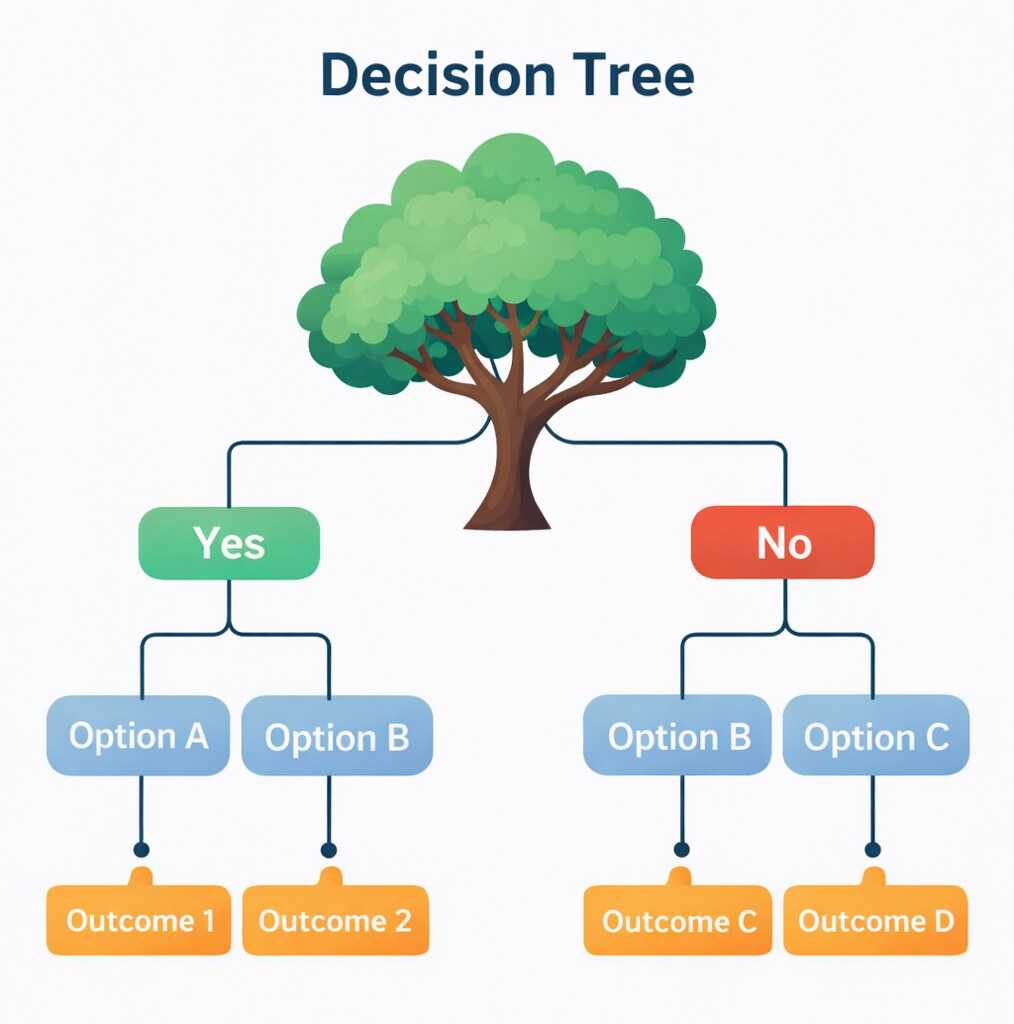


## Introduction

In machine learning, we like to train models. However, the work starts much earlier: with selecting hyperparameters and transforming data. A decision tree splits the feature space into rectangular regions using thresholds on individual features. Its effectiveness depends, among other things, on whether it can separate points from different classes in the data, how much noise there is — and on its own hyperparameters such as depth or minimum number of samples in a leaf.

## Task

Create an algorithm that **automatically**, based on a training dataset, performs data preprocessing and selects hyperparameters of a decision tree so that the final tree achieves the best possible performance on the preprocessed test set. You should provide two functions: `preprocess_data(X_train, X_test)`, which returns transformed `X_train` and `X_test` **with the same dimensions** as the input matrices, and `get_decision_tree_hyperparameters(X_train, y_train)`, which returns a dictionary of hyperparameters.

## Data

A collection of 100 datasets named **A** is available in the files:

* `A_input.npz` — contains for each dataset `i` (from 0 to 99):

  * `X_i` — training matrix (n_train_i × 2)
  * `y_i` — training label vector (n_train_i,), values 0 or 1
  * `X_test_i` — test matrix (n_test_i × 2)

* `A_output.npz` — contains:

  * `y_test_i` — test label vector (n_test_i,), 0/1
  * `baseline_acc` — vector of baseline performance results of our method (n_datasets,), floating-point values

Both files contain the field `n_datasets = 100`.

The datasets differ from each other: they may have different grid sizes, overlapping regions, noise, rotated data, probabilistic labels, etc. They may also have different numbers of samples.

Your solution will be tested on a **hidden collection B**, with the same format and number of datasets. You will not have access to it during the competition.

## Evaluation Criterion

For each dataset in the collection, you can earn 0 or 1.2 points depending on whether the decision tree trained using your hyperparameters and data preprocessing achieves higher accuracy than our baseline solution. There are 100 datasets in total, so the maximum score is 120 points. The final score is capped at 100.

## Constraints

* Your solution will be evaluated on the competition platform **without internet access**.
* Final evaluation runtime must not exceed **3 minutes** (CPU only, no GPU).
* Allowed libraries: `scikit-learn`, `numpy`, `pandas`.

## Submission Files

This notebook completed with your solution (see functions `get_decision_tree_hyperparameters` and `preprocess_data`).

## Evaluation

During evaluation, the flag `FINAL_EVALUATION_MODE` will be set to `True`. The score will be computed on a hidden test set on the competition platform. If the solution does not meet requirements or fails to execute properly, it will receive 0 points.

# Starter Code

In this section we initialize the environment by importing the required libraries and setting the random seed.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################
FINAL_EVALUATION_MODE = False # During evaluation on the grader, this flag is automatically set to True.

In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################

import random
import numpy as np
from sklearn.tree import DecisionTreeClassifier

if not FINAL_EVALUATION_MODE:
    import matplotlib.pyplot as plt


seed = 42
random.seed(seed)
np.random.seed(seed)

## Data Loading

File format:

* `A_input.npz`: `X_0`, `y_0`, `X_test_0`, ..., `X_99`, `y_99`, `X_test_99`, `n_datasets`
* `A_output.npz`: `y_test_0`, ..., `y_test_99`, `n_datasets`, `baseline_acc`

Where:

* `X_i` — training feature matrix (n_train × 2, float32),
* `y_i` — training labels (n_train, int8, values 0/1),
* `X_test_i` — test feature matrix (n_test × 2, float32),
* `y_test_i` — test labels (n_test, int8).


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################

def load_data(prefix="A"):
    input_data = np.load(f'data/{prefix}_input.npz')
    output_data = np.load(f'data/{prefix}_output.npz')
    n = int(input_data['n_datasets'])
    print(f"\n{prefix}: {n} datasets")
    for i in range(min(n, 3)):
        X_tr = input_data[f'X_{i}']
        y_tr = input_data[f'y_{i}']
        X_te = input_data[f'X_test_{i}']
        y_te = output_data[f'y_test_{i}']
        print(f"  Dataset {i}: train={X_tr.shape}, test={X_te.shape}, "
              f"num_1s={y_tr.sum()}, num_0s={(y_tr == 0).sum()}")
    print("  ...")
    return n, input_data, output_data


n, input_data, output_data = load_data()

## Data Inspection

Visualization of selected datasets from collection A. For each selected dataset, we train a default decision tree and plot the training points along with the decision regions.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################

def extract_regions(tree, feature_names=None, node=0, bounds=None):
    """
    Recursively extracts rectangular regions from a decision tree.
    Returns a list of (bounds, predicted_class) for each leaf node.
    """
    if bounds is None:
        n_features = tree.n_features
        bounds = [(-np.inf, np.inf) for _ in range(n_features)]

    if tree.children_left[node] == tree.children_right[node]:
        return [(bounds, np.argmax(tree.value[node]))]

    feature = tree.feature[node]
    threshold = tree.threshold[node]

    regions = []

    left_bounds = bounds.copy()
    left_bounds[feature] = (left_bounds[feature][0], min(left_bounds[feature][1], threshold))
    regions.extend(extract_regions(tree, feature_names, tree.children_left[node], left_bounds))

    right_bounds = bounds.copy()
    right_bounds[feature] = (max(right_bounds[feature][0], threshold), right_bounds[feature][1])
    regions.extend(extract_regions(tree, feature_names, tree.children_right[node], right_bounds))
    return regions


def plot_dataset_with_tree(X_train, y_train, X_test, y_test, tree_params=None, ax=None, title=""):
    """Plots the dataset together with the decision regions of a trained tree."""
    if tree_params is None:
        tree_params = {"max_depth": 10, "ccp_alpha": 0.01}
    if ax is None:
        _, ax = plt.subplots(1, 1, figsize=(5, 5))

    tree = DecisionTreeClassifier(**tree_params)
    tree.fit(X_train, y_train)
    acc = tree.score(X_test, y_test)

    regions = extract_regions(tree.tree_)
    colors = ['lightcoral', 'lightblue']
    for bounds, label in regions:
        (x0, x1), (y0, y1) = bounds
        if np.isinf(x0): x0 = X_train[:, 0].min() - 0.5
        if np.isinf(x1): x1 = X_train[:, 0].max() + 0.5
        if np.isinf(y0): y0 = X_train[:, 1].min() - 0.5
        if np.isinf(y1): y1 = X_train[:, 1].max() + 0.5
        ax.fill_between([x0, x1], y0, y1, color=colors[label % 2], alpha=0.25)

    ax.scatter(X_train[:, 0], X_train[:, 1], c=1-y_train, cmap='bwr', s=3, alpha=0.6)
    ax.set_title(f"{title}\nacc={acc:.3f}, nodes={tree.tree_.node_count}", fontsize=9)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=6)
    return acc


if not FINAL_EVALUATION_MODE:
    # Visualization of 10 selected datasets from collection A
    sample_ids = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
    fig, axes = plt.subplots(2, 5, figsize=(25, 10))
    for j, i in enumerate(sample_ids):
        X_tr = input_data[f'X_{i}']
        y_tr = input_data[f'y_{i}']
        X_te = input_data[f'X_test_{i}']
        y_te = output_data[f'y_test_{i}']
        ax = axes[j // 5, j % 5]
        plot_dataset_with_tree(X_tr, y_tr, X_te, y_te, ax=ax, title=f"Dataset {i}")
    plt.tight_layout()
    plt.show()

## Your Solution

In this section, place your solution. Implement the following functions:

* `get_decision_tree_hyperparameters(X_train, X_test)`, which returns a dictionary of decision tree hyperparameters,
* `preprocess_data(X_train, X_test)`, which returns the processed data. The resulting matrices must have the same dimensions as the corresponding input matrices.

Example decision tree hyperparameters:

* `max_depth` — maximum depth of the tree,
* `min_samples_split` — minimum number of samples required to split an internal node,
* `min_samples_leaf` — minimum number of samples required to be at a leaf node,
* `max_features` — number of features considered when looking for the best split.


In [ ]:
def preprocess_data(X_train, X_test):
    """
    Preprocessing of data.
    """
    # TODO: insert your solution here!
    return X_train, X_test


def get_decision_tree_hyperparameters(X_train, y_train):
    """
    Selection of decision tree hyperparameters.
    """
    # TODO: insert your solution here!
    return {"max_depth": 3}

## Evaluation

Running the cell below allows you to check how many points your solution would obtain on the datasets from group **A**, available during the competition. Before submitting, make sure that the entire notebook executes from start to finish without errors and without requiring any user interaction after selecting “Run All”.

During evaluation, the model will be tested on a hidden group **B** of datasets using an evaluation function with a similar mechanism.


In [ ]:
######################### DO NOT MODIFY THIS CELL WHEN SUBMITTING ##########################

if not FINAL_EVALUATION_MODE:
    baseline_acc = output_data['baseline_acc']
    beats_baseline = 0
    accuracies = []
    for i in range(n):
        X_train = input_data[f'X_{i}']
        y_train = input_data[f'y_{i}']
        X_test = input_data[f'X_test_{i}']
        y_test = output_data[f'y_test_{i}']
        X_train_shape = X_train.shape
        X_test_shape = X_test.shape

        X_train_proc, X_test_proc = preprocess_data(X_train, X_test)
        assert X_test_shape == X_test_proc.shape
        assert X_train_shape == X_train_proc.shape

        hyperparameters = get_decision_tree_hyperparameters(X_train_proc, y_train)

        model = DecisionTreeClassifier(**hyperparameters)
        model.fit(X_train_proc, y_train)

        accuracy = model.score(X_test_proc, y_test)
        accuracies.append(accuracy)

        if accuracy >= baseline_acc[i]:
            beats_baseline += 1

    mean_acc = np.mean(accuracies)
    print(f"\nFinal result:")
    print(f"  Datasets evaluated: {n}")
    print(f"  Mean accuracy:      {mean_acc:.4f}")
    print(f"  Beats baseline:     {beats_baseline} / {n}")
    print(f"  Points:             {min(beats_baseline * 1.2, 100)}")